In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# data load and EDA

In [21]:
data = pd.read_csv("online_shoppers.csv")
data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,S-100000,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,S-100001,0,0.0,0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,S-100002,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,S-100003,0,0.0,0,NaN,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,S-100004,0,0.0,0,NaN,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,NaN,True,False


In [22]:
columns = data.select_dtypes(include="number").columns

columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

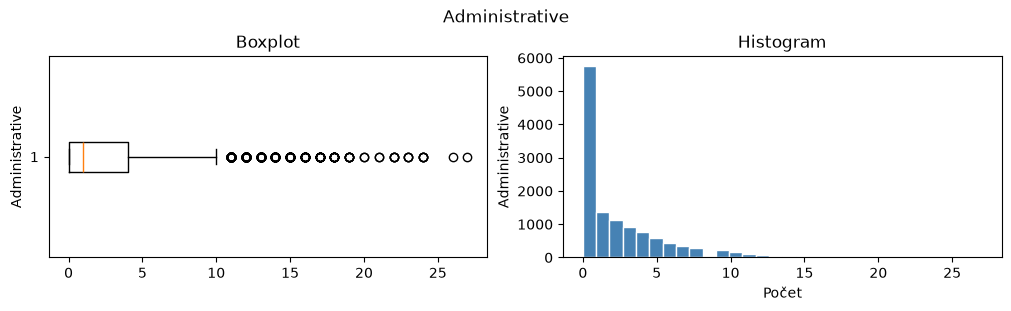

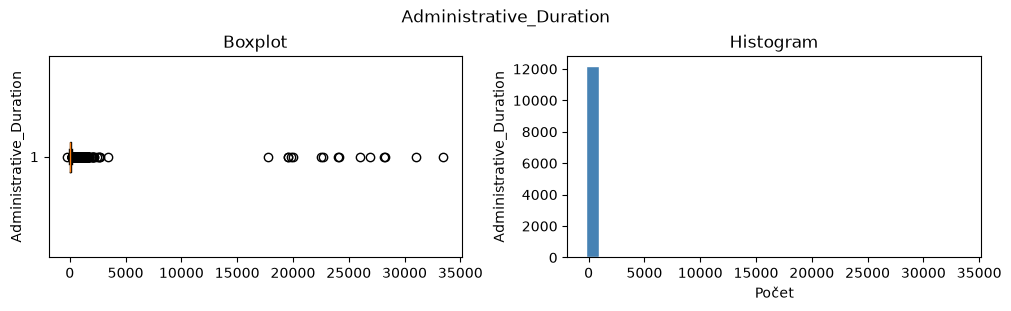

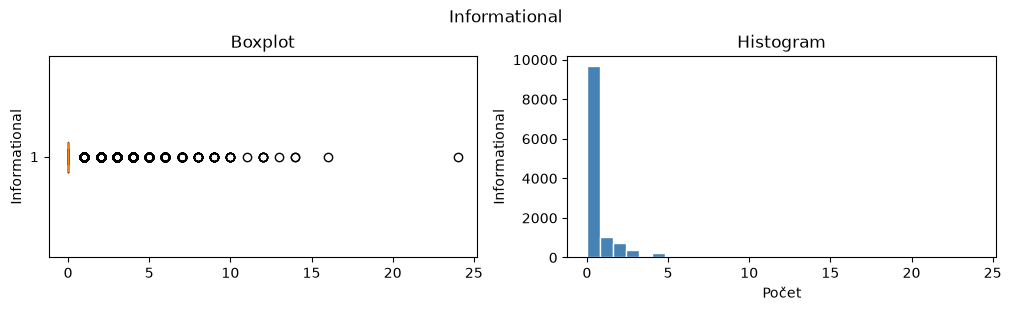

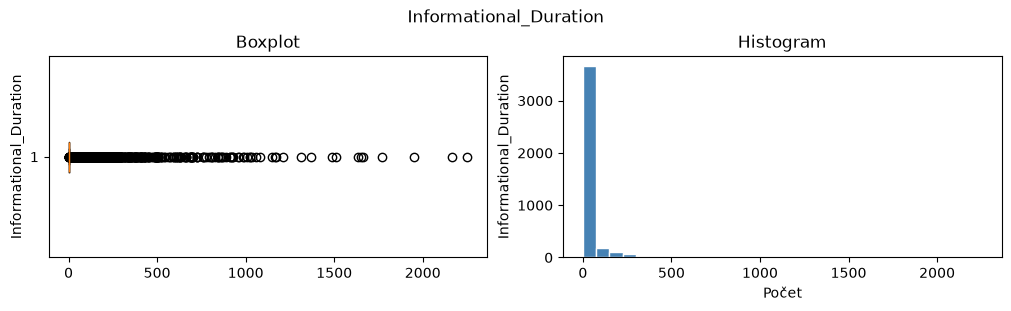

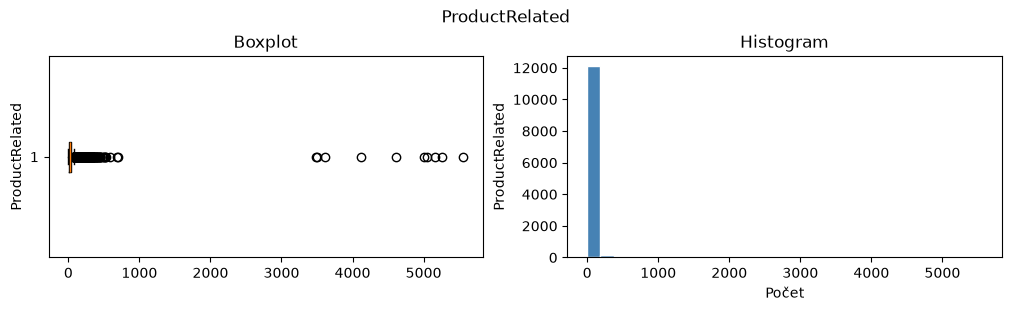

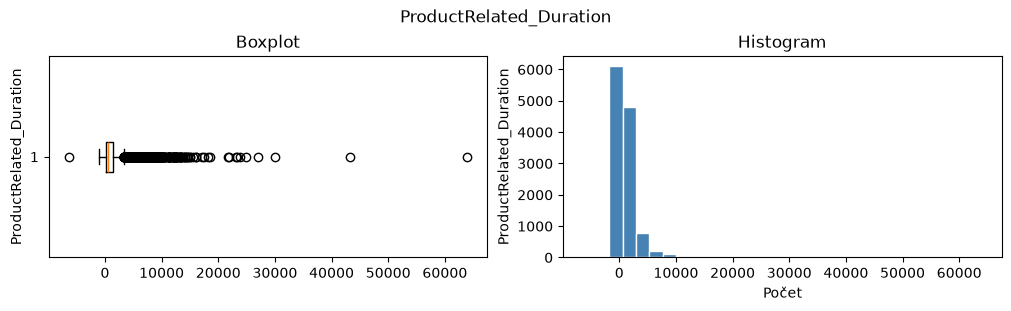

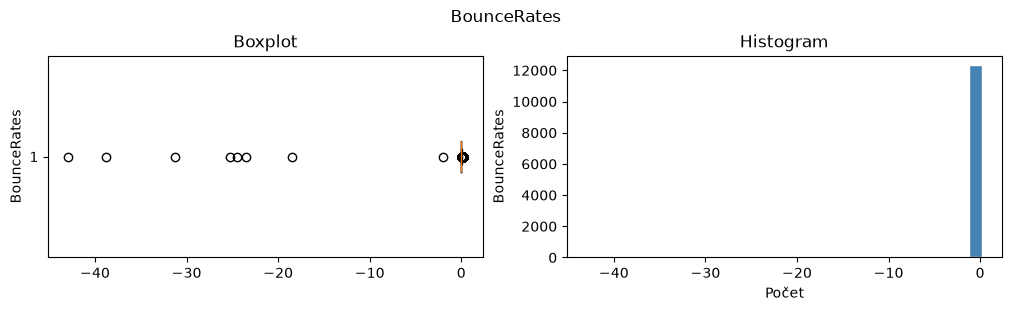

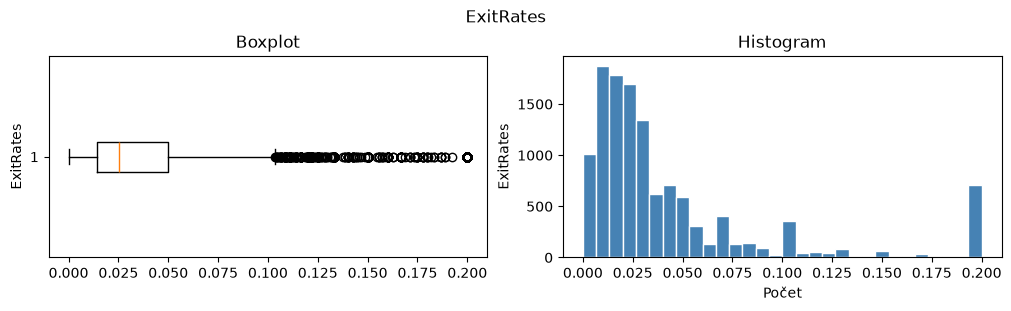

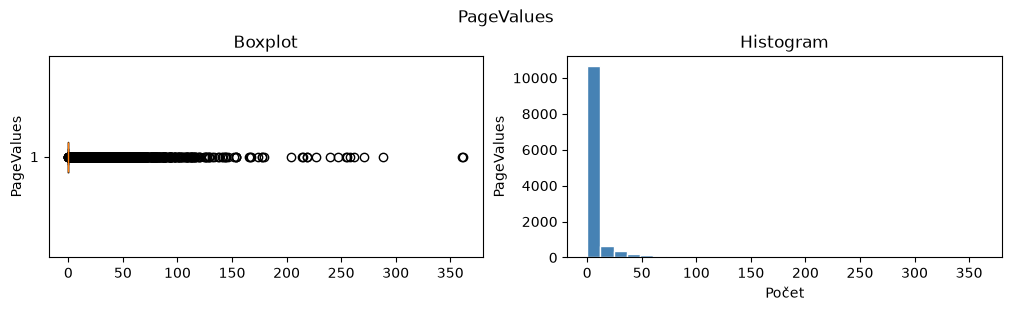

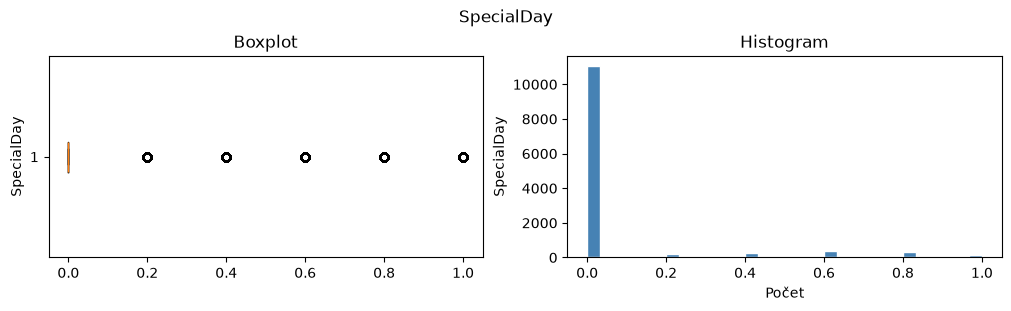

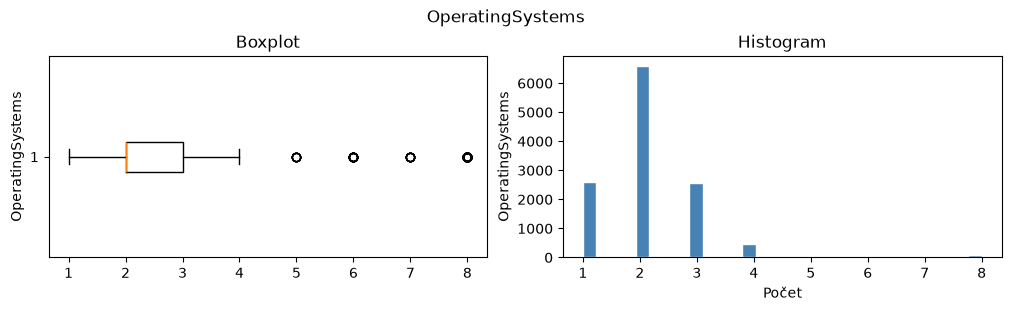

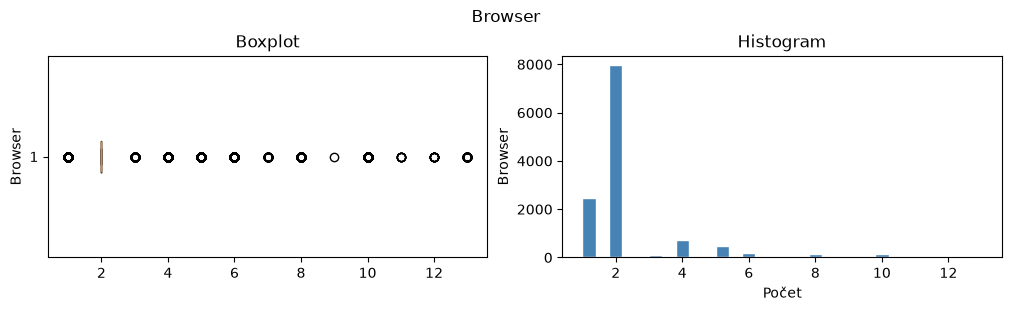

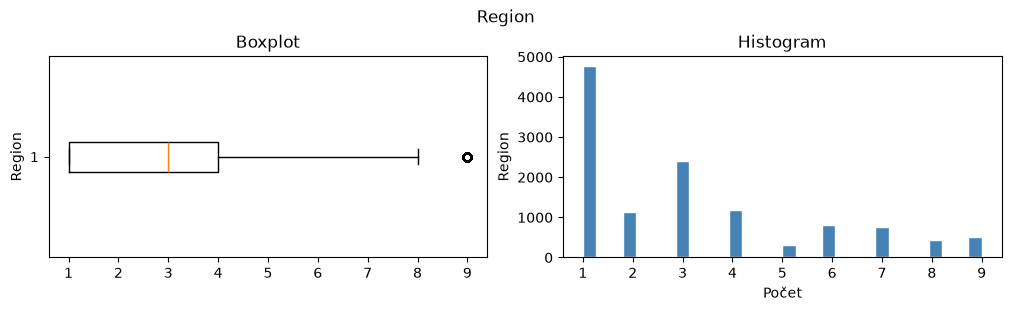

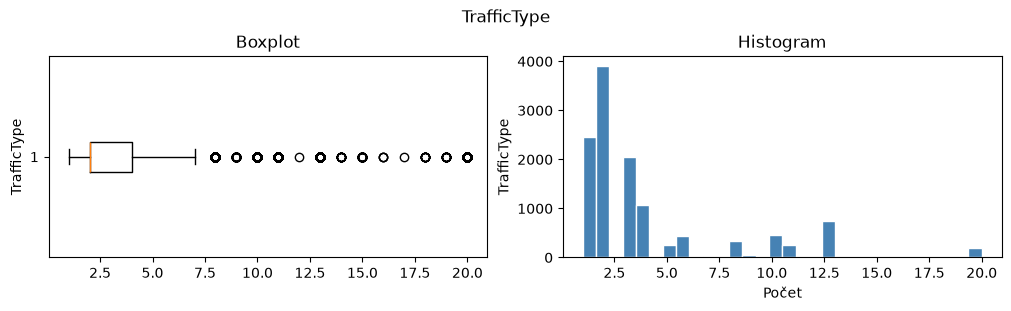

In [23]:
for column in columns:
    values = data[column].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
    axes[0].boxplot(values, orientation="horizontal")
    axes[0].set(title="Boxplot", ylabel=column)
    axes[1].hist(values, bins=30, color="steelblue", edgecolor="white")
    axes[1].set(title="Histogram", xlabel="Počet", ylabel=column)
    fig.suptitle(column)
    plt.show()

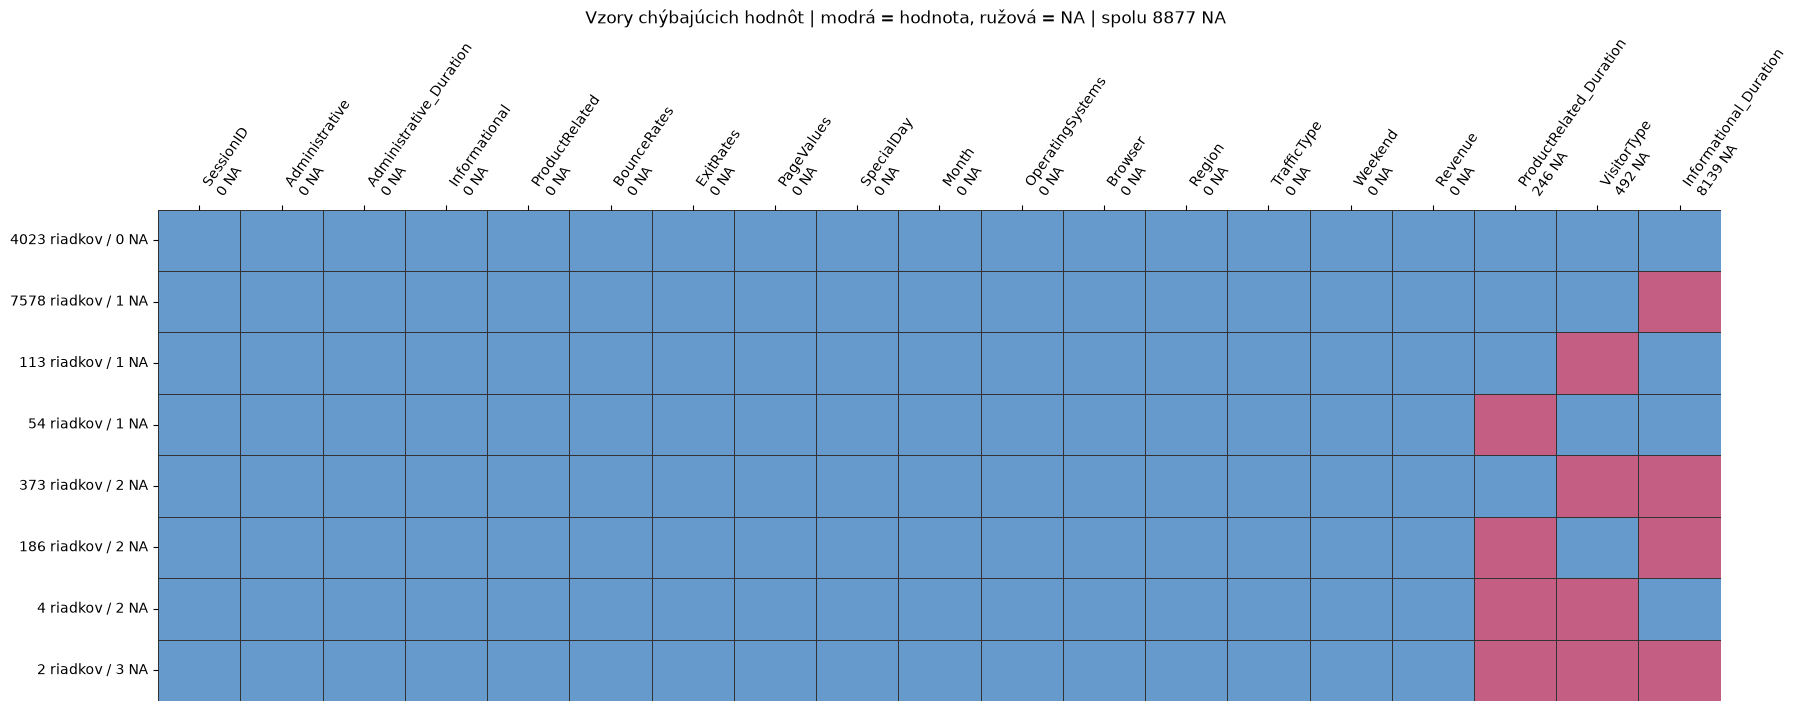

In [24]:
missing = data.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

- v cca 2/3 (8139/12334) dat chyba hodnota (NA) v poslednom stlpci Informational_Duration, co neni ani vhodne doplnat/nahradzat, preto tento stlpec je jednoduchsie a lepsie dropnut
- taktiez mozme dropnut indexy (rows) riadky, ktore su na grafe zobrazene ako posledne 2 kde chyba v 2 riadkoch 3 hodnoty a v 4 riadkoch 2 hodnoty

In [25]:
# dropnutie stlpca a riadkov
rows_to_drop = data["ProductRelated_Duration"].isna() | data["VisitorType"].isna()
data_clean = data.drop(index=data.index[rows_to_drop], columns="Informational_Duration").copy()

In [26]:
data_clean.describe()

,Administrative,Administrative_Duration,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000
mean,2.326437,112.502691,0.507801,35.006637,1199.481299,0.004117,0.042697,6.154971,0.061546,2.122662,2.351608,3.140160,4.077752
std,3.327508,901.008974,1.270743,127.664326,1918.490414,0.748188,0.048397,19.006150,0.199062,0.910592,1.708669,2.394896,4.027833
min,0.000000,-214.548633,0.000000,0.000000,-6423.973010,-42.953427,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,7.000000,185.000000,0.000000,0.014251,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,8.000000,0.000000,18.000000,604.000000,0.003014,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.600000,0.000000,38.000000,1467.654221,0.016667,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,33466.707646,24.000000,5258.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### removing outliers

In [27]:
def remove_outliers(df):
    counts = ["Administrative", "Informational", "ProductRelated"]
    nonnegative = counts + [
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "PageValues",
    ]

    bounds = {column: (0, np.inf) for column in nonnegative}
    bounds.update({
        "BounceRates": (0, 1),
        "ExitRates": (0, 1),
        "SpecialDay": (0, 1),
    })

    categories = {
        "OperatingSystems": range(1, 9),
        "Browser": range(1, 14),
        "Region": range(1, 10),
        "TrafficType": range(1, 21),
        "Month": ["Feb", "Mar", "May", "June", "Jul",
                  "Aug", "Sep", "Oct", "Nov", "Dec"],
        "VisitorType": ["Returning_Visitor", "New_Visitor", "Other"],
        "Weekend": [True, False],
        "Revenue": [True, False],
    }

    valid = pd.Series(True, index=df.index)

    for column, (lower, upper) in bounds.items():
        if column not in df.columns:
            continue

        values = df[column]
        valid &= values.isna() | (
            values.between(lower, upper) & np.isfinite(values)
        )

        if column in counts:
            valid &= values.isna() | values.mod(1).eq(0)

    for column, allowed in categories.items():
        values = df[column]
        valid &= values.isna() | values.isin(allowed)

    return df.loc[valid].copy()

In [28]:
before = len(data_clean)
data_clean = remove_outliers(data_clean)

before, len(data_clean)

(11601, 11583)

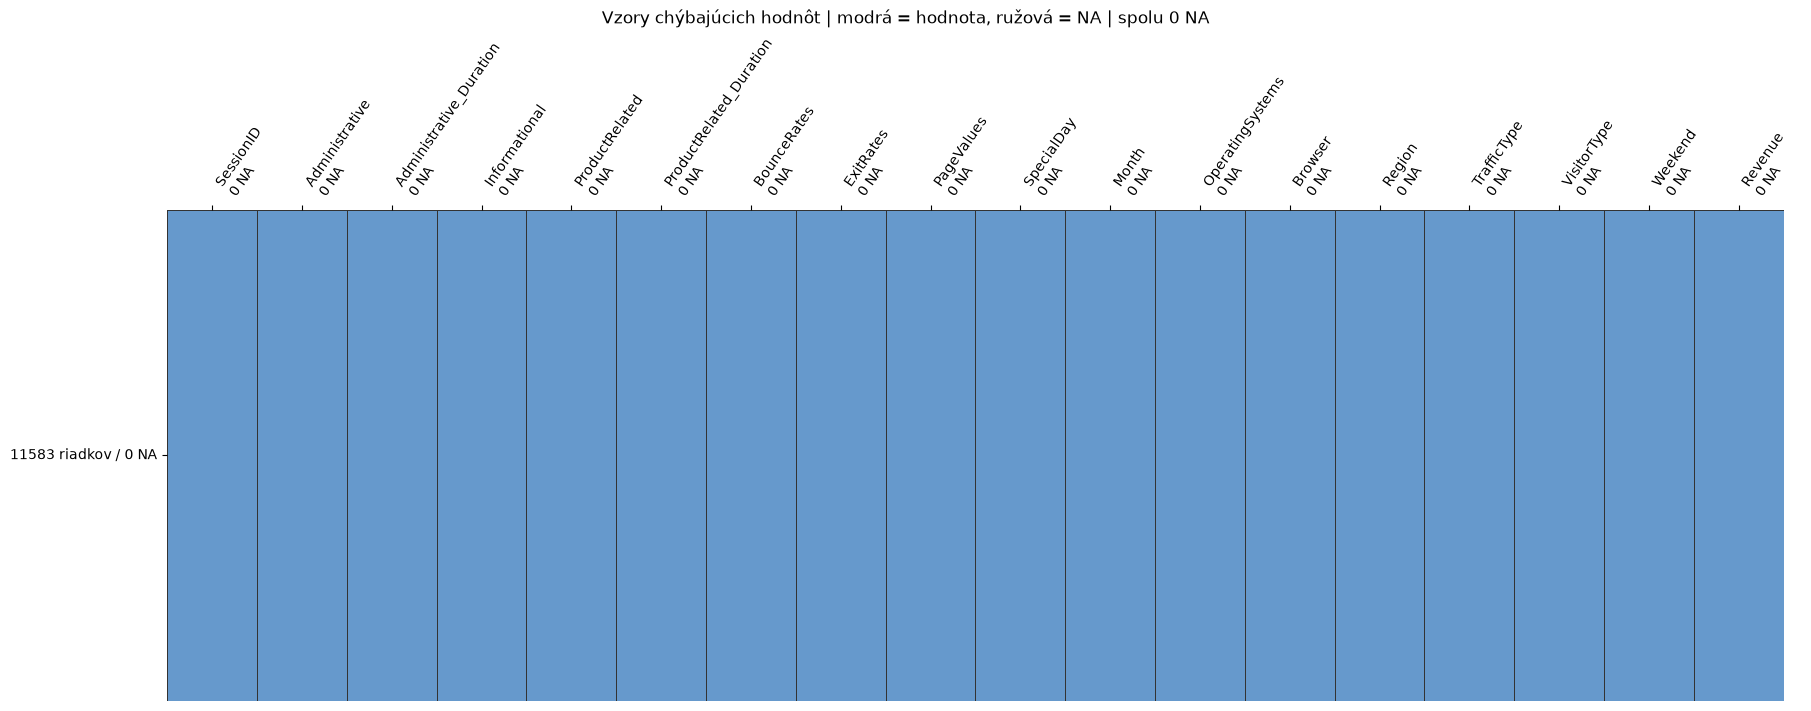

In [29]:
missing = data_clean.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data_clean.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

## VisitorType vs ProductRelated a PageValues

In [30]:
visitor_types = ["Returning_Visitor", "New_Visitor", "Other"]
visitor_data = data_clean[data_clean["VisitorType"].isin(visitor_types)].copy()
for metric in ["PageValues", "ProductRelated"]:
    visitor_data[f"log1p_{metric}"] = np.log1p(visitor_data[metric])

visitor_data["VisitorType"].value_counts().reindex(visitor_types)

VisitorType
Returning_Visitor    9912
New_Visitor          1593
Other                  78
Name: count, dtype: int64

pouzity $\log{(1 + x)}$ (log1p), kvoli normalizacii velmi odlahlych hodnot a obsahovani 0 hodnot, logaritmus 1+x zachova 0 na 0, normalizacia zachovana aj kvoli porovnaniu roznych skupin

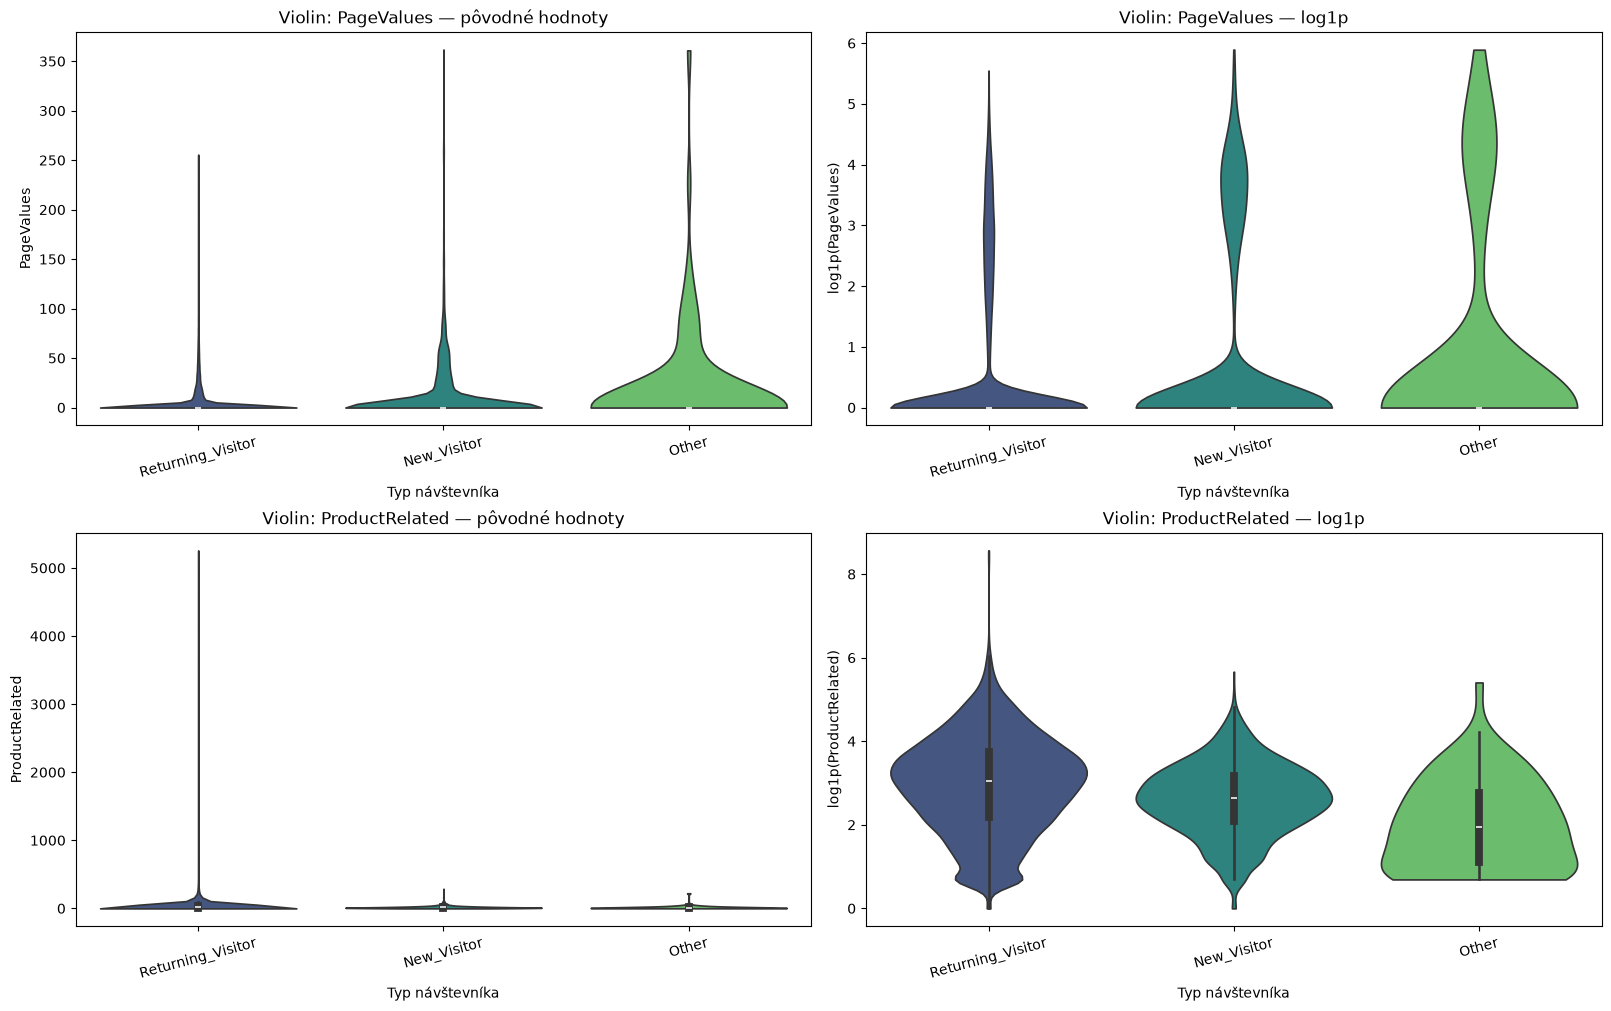

In [31]:
visitor_palette = dict(zip(visitor_types, sns.color_palette("viridis", len(visitor_types))))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.violinplot(
            data=visitor_data, x="VisitorType", y=value_column,
            order=visitor_types, hue="VisitorType", hue_order=visitor_types,
            palette=visitor_palette, dodge=False, legend=False,
            inner="box", cut=0,
            ax=ax,
        )
        ax.set(title=f"Violin: {metric} — {variant_label}",
               xlabel="Typ návštevníka", ylabel=value_label)
        ax.tick_params(axis="x", rotation=15)

plt.show()


Pri PageValues sa vo vsetkych skupinach vacsina hodnot sustreduje pri nule. Rozdelenia maju dlhe chvosty, kde sa tahaju k vysokym hodnotam. Transformacia $log1p$ zlepsuje zobrazenie hodnot, kde je vidno ze v skupine Other je hustota posunuta k vyssim hodnotam nez pri vracajucich sa navstevnikov.

Pri ProductRelated povodnu mierku vyrazne ovplyvnuju extremne hodnoty vracajucich sa navstevnikov. Po transformacii su rozdiely citatelnejsie, kde vracajuci sa navstevnivi maju najvyssi median a najnizsi ostatny typ navstevnikov. Vracajuci navstevnici navstevuju viac produktovo suvisiacich stranok.

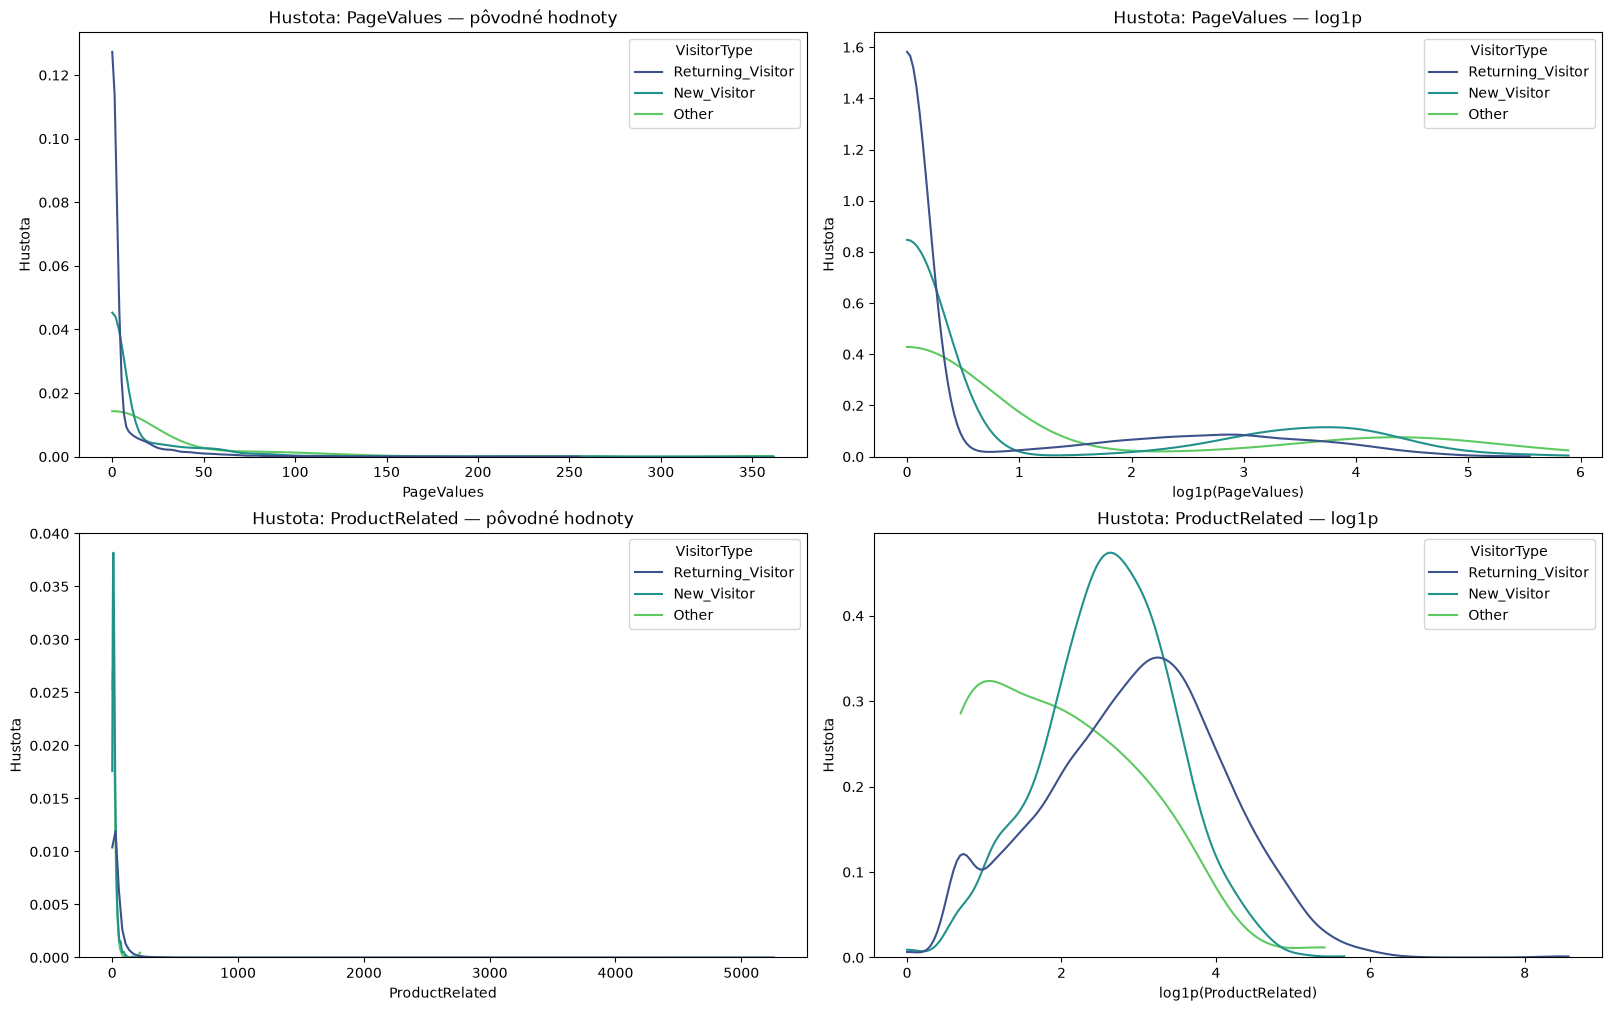

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.kdeplot(
            data=visitor_data, x=value_column, hue="VisitorType",
            hue_order=visitor_types, palette=visitor_palette,
            common_norm=False,
            cut=0,
            ax=ax,
        )
        ax.set(title=f"Hustota: {metric} — {variant_label}",
               xlabel=value_label, ylabel="Hustota")

plt.show()


Pri PageValues vidime vyrazny vrchol pri nule a dlhy chvost pri vsetkych skupinach. Pri nule je najhustejsia skupina vracajucich sa zakaznikov, pri skupinach New_Visitor a Other su hodnoty sirsie.

Pri ProductRelated je najvyssia hodnota v skupine novych zakaznikov v oblasti medzi 2 a 4 (os logaritmu skupiny). Skupina Other ma najhustejsiu hodnotu blizsie k nule a vracajuci sa zakaznici maju najhustejsiu hodnotu vo vyssich hodnotach.

## Mesiac návštevy a nákup (Month × Revenue)

Porovnávame podiel session ukončených nákupom v jednotlivých mesiacoch v pôvodnom a upravenom datasete. Podiel počítame ako počet nákupov delený počtom session v danom mesiaci. Vľavo body zobrazujú mesačné podiely a chybové úsečky ich 95 % Wilsonove intervaly spoľahlivosti. Tie vyjadrujú neistotu odhadu pri predpoklade nezávislých session. Body nespájame čiarami, pretože január a apríl v datasete chýbajú.

Vpravo boxplot sumarizuje rozdelenie desiatich mesačných podielov pre každý dataset. Tabuľka pod grafom obsahuje počty session, počty nákupov, percentuálne podiely a hranice intervalov v percentách.

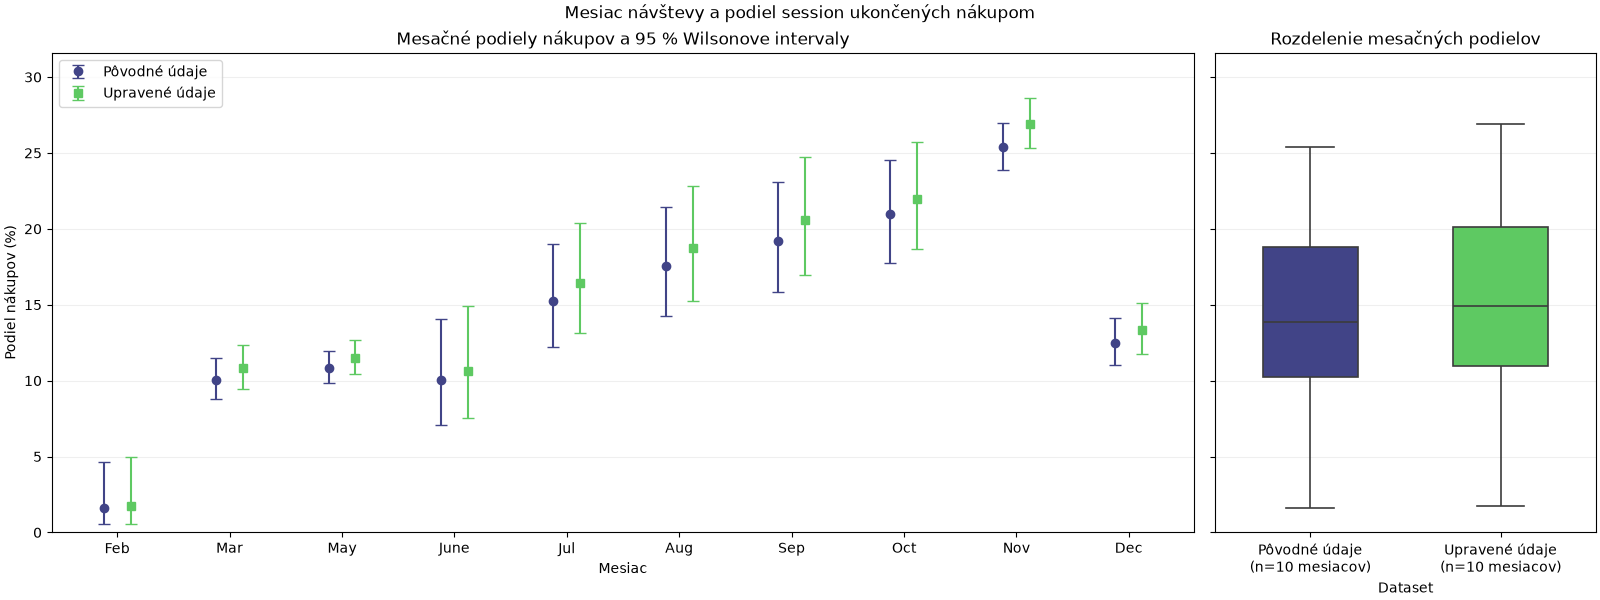

Pôvodné údaje                                           Upravené údaje                                          
           sessions purchases purchase_rate ci_lower ci_upper       sessions purchases purchase_rate ci_lower ci_upper
Month                                                                                                                 
Feb             185         3          1.62     0.55     4.66            174         3          1.72     0.59     4.95
Mar            1907       192         10.07     8.80    11.50           1775       192         10.82     9.46    12.35
May            3365       365         10.85     9.84    11.94           3171       365         11.51    10.45    12.67
June            288        29         10.07     7.10    14.09            272        29         10.66     7.53    14.89
Jul             432        66         15.28    12.19    18.98            401        66         16.46    13.15    20.40
Aug             433        76         17.55    14.26    21.42            405        76         18.77    15.26    22.85
Sep             448        86         19.20    15.82    23.10            418        86         20.57    16.98    24.71
Oct             549       115         20.95    17.75    24.55            523       115         21.99    18.65    25.74
Nov            2999       761         25.38    23.85    26.96           2826       761         26.93    25.33    28.59
Dec            1727       216         12.51    11.03    14.15           1618       216         13.35    11.78    15.09

In [ ]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
datasets = {"Pôvodné údaje": data, "Upravené údaje": data_clean}
month_summary = {}
colors = plt.get_cmap("viridis")([0.2, 0.75])
positions = np.arange(len(month_order))
z = 1.959963984540054

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), sharey=True,
    gridspec_kw={"width_ratios": [3, 1]}, constrained_layout=True
)

for i, (label, frame) in enumerate(datasets.items()):
    monthly = (
        frame.dropna(subset=["Month", "Revenue"])
        .groupby("Month")["Revenue"]
        .agg(sessions="size", purchases="sum", purchase_rate="mean")
        .reindex(month_order)
    )
    sessions = monthly["sessions"]
    proportion = monthly["purchase_rate"]
    denominator = 1 + z**2 / sessions
    center = (proportion + z**2 / (2 * sessions)) / denominator
    half_width = (
        z * np.sqrt(
            proportion * (1 - proportion) / sessions
            + z**2 / (4 * sessions**2)
        ) / denominator
    )
    monthly["purchase_rate"] *= 100
    monthly["ci_lower"] = (center - half_width).clip(0, 1) * 100
    monthly["ci_upper"] = (center + half_width).clip(0, 1) * 100
    month_summary[label] = monthly

    rate = monthly["purchase_rate"]
    axes[0].errorbar(
        positions + (i - 0.5) * 0.24,
        rate,
        yerr=np.maximum(np.vstack([
            rate - monthly["ci_lower"], monthly["ci_upper"] - rate
        ]), 0),
        fmt=["o", "s"][i],
        linestyle="none",
        color=colors[i],
        capsize=4,
        markersize=6,
        label=label,
    )

axes[0].set(
    title="Mesačné podiely nákupov a 95 % Wilsonove intervaly",
    xlabel="Mesiac",
    ylabel="Podiel nákupov (%)",
    xticks=positions,
    xticklabels=month_order,
    ylim=(0, max(table["ci_upper"].max() for table in month_summary.values()) + 3),
)
axes[0].legend()

monthly_rates = pd.DataFrame({
    label: table["purchase_rate"] for label, table in month_summary.items()
})
sns.boxplot(
    data=monthly_rates, palette=list(colors), saturation=1,
    width=0.5, linewidth=1.2, ax=axes[1],
)
axes[1].set(title="Rozdelenie mesačných podielov", xlabel="Dataset", ylabel="")
axes[1].set_xticks(
    np.arange(len(datasets)),
    labels=[
        f"{label}\n(n={monthly_rates[label].count()} mesiacov)"
        for label in datasets
    ],
)
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)

fig.suptitle("Mesiac návštevy a podiel session ukončených nákupom")
plt.show()

pd.concat(month_summary, axis=1).round(2)


Najvyšší podiel nákupov má november: približne 25,4 % v pôvodných a 26,9 % v upravených údajoch. Vo februári dosahuje podiel iba približne 1,6 % a 1,7 %. Rozdiely naznačujú súvislosť medzi mesiacom návštevy a nákupným správaním v tomto datasete, ale samy osebe nepotvrdzujú všeobecnú sezónnosť ani jej príčinu.

Intervaly spoľahlivosti dopĺňajú informáciu o presnosti odhadov, ktorá závisí od počtu session aj od samotného podielu nákupov. Napríklad máj má užší interval než august, ktorý obsahuje podstatne menej session.

Pri aktuálnom čistení boli odstránené iba session bez nákupu. Počet nákupov preto zostal rovnaký, kým počet session klesol, čo zvýšilo podiel nákupov v upravených údajoch. Pôvodný a upravený dataset sa prekrývajú, preto nejde o dva nezávislé výbery a graf sám osebe nie je testom významnosti rozdielov medzi nimi.

Boxplot vpravo sumarizuje medián, kvartily a rozsah mesačných podielov nákupov. Každý mesiac predstavuje jedno pozorovanie a má rovnakú váhu, hoci počty session sa medzi mesiacmi líšia. Boxplot tak dopĺňa porovnanie konkrétnych mesiacov v bodovom grafe.

## Produktové stránky a miera odchodu (ProductRelated × ExitRates)

Hexbin graf zobrazuje počet produktových stránok oproti priemernej miere odchodu zo stránok navštívených v session. Os x používa log1p, ktorý zachováva nuly a zlepšuje čitateľnosť veľkého rozsahu počtu stránok. Farba vyjadruje počet session v hexagóne; oba grafy majú rovnaké osi, rozdelenie hexagónov a spoločnú logaritmickú farebnú škálu. Chýbajúce hodnoty v tejto dvojici stĺpcov vynechávame.

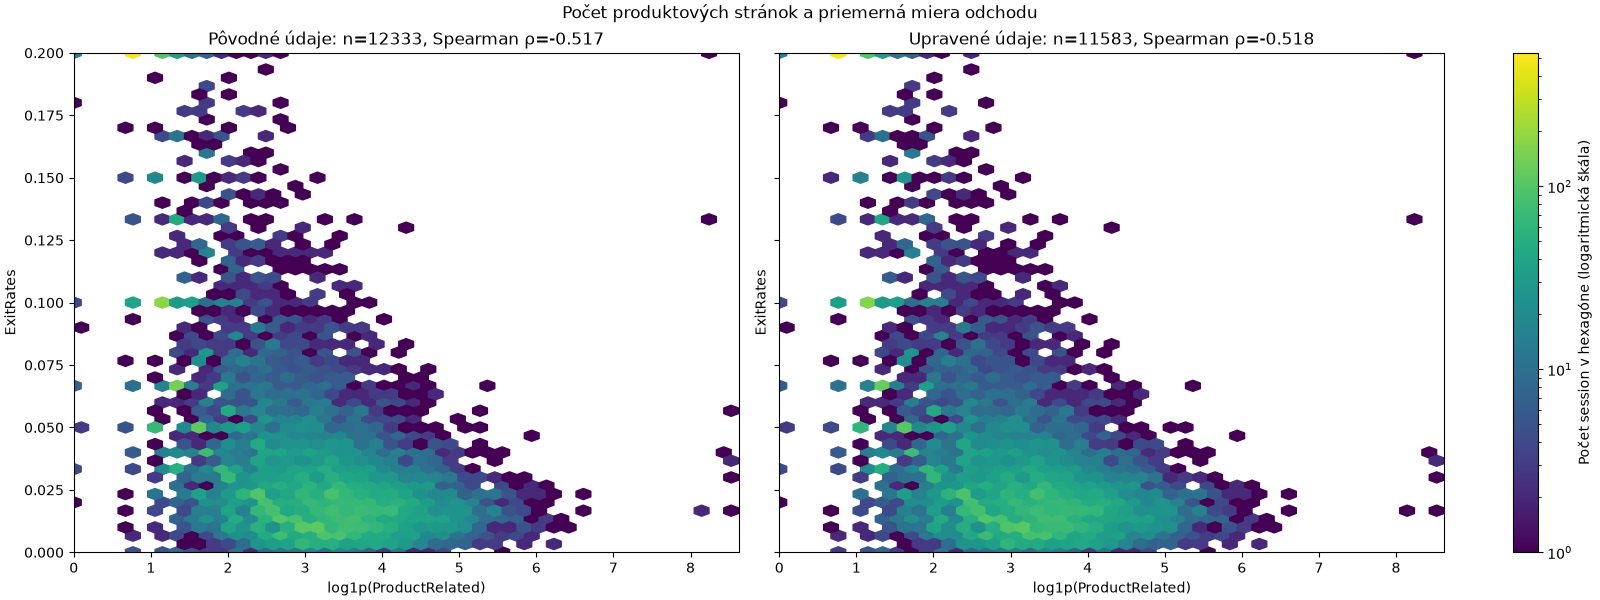

,Počet session,Spearman
Dataset,,
Pôvodné údaje,12333,-0.517
Upravené údaje,11583,-0.518


In [ ]:
from matplotlib.colors import LogNorm

datasets = {"Pôvodné údaje": data, "Upravené údaje": data_clean}
exit_pairs = {
    label: frame[["ProductRelated", "ExitRates"]].dropna()
    for label, frame in datasets.items()
}
extent = (
    0,
    max(np.log1p(pair["ProductRelated"]).max() for pair in exit_pairs.values()),
    0,
    max(pair["ExitRates"].max() for pair in exit_pairs.values()),
)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), sharex=True, sharey=True, constrained_layout=True
)
hexagons = []
exit_summary = []

for ax, (label, pair) in zip(axes, exit_pairs.items()):
    correlation = pair.corr(method="spearman").loc["ProductRelated", "ExitRates"]
    hexagons.append(ax.hexbin(
        np.log1p(pair["ProductRelated"]),
        pair["ExitRates"],
        gridsize=(45, 30),
        extent=extent,
        mincnt=1,
        cmap="viridis",
    ))
    ax.set(
        title=f"{label}: n={len(pair)}, Spearman ρ={correlation:.3f}",
        xlabel="log1p(ProductRelated)",
        ylabel="ExitRates",
        xlim=extent[:2],
        ylim=extent[2:],
    )
    exit_summary.append({
        "Dataset": label,
        "Počet session": len(pair),
        "Spearman": correlation,
    })

density_norm = LogNorm(
    vmin=1, vmax=max(2, max(grid.get_array().max() for grid in hexagons))
)
for grid in hexagons:
    grid.set_norm(density_norm)

fig.colorbar(hexagons[0], ax=axes, label="Počet session v hexagóne (logaritmická škála)")
fig.suptitle("Počet produktových stránok a priemerná miera odchodu")
plt.show()

pd.DataFrame(exit_summary).set_index("Dataset").round(3)


S rastúcim počtom navštívených produktových stránok má priemerná miera odchodu tendenciu klesať. Spearmanova korelácia je približne −0,52 v pôvodnom aj upravenom datasete, takže vzťah zostáva podobný aj po čistení.

V upravených údajoch je medián ExitRates približne 0,200 pri 0–1 produktových stránkach a 0,017 pri viac ako 50 produktových stránkach. Ide o zápornú súvislosť medzi rozsahom prehliadania a priemernou mierou odchodu; nepreukazuje, že viac produktových stránok priamo spôsobuje nižšiu mieru odchodu.

## correlation of productrelated and time on them

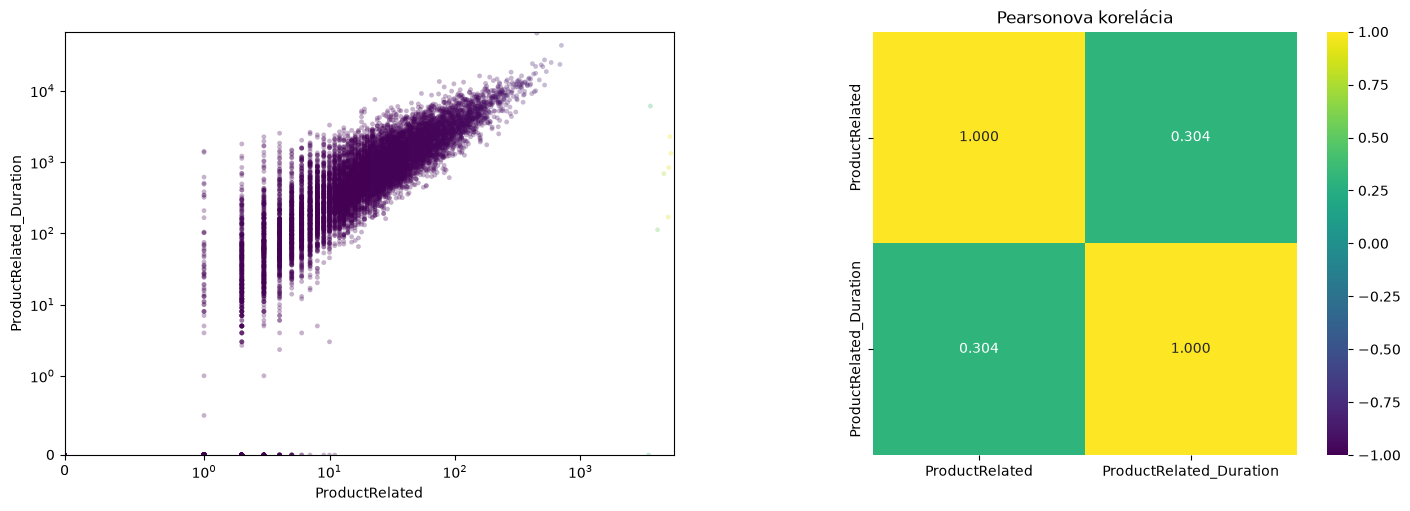

In [37]:
product_pair = data_clean[["ProductRelated", "ProductRelated_Duration"]].dropna()
pearson = product_pair.corr(method="pearson").iloc[0, 1]
spearman = product_pair.corr(method="spearman").iloc[0, 1]

pearson, spearman, len(product_pair)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sns.scatterplot(
    data=product_pair,
    x="ProductRelated",
    y="ProductRelated_Duration",
    hue="ProductRelated",
    palette="viridis",
    legend=False,
    alpha=0.3,
    s=12,
    edgecolor="none",
    ax=axes[0],
)

axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)

sns.heatmap(
    product_pair.corr(method="pearson"),
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Pearsonova korelácia")
plt.show()

In [36]:
X = data_clean.drop(columns=["SessionID", "Revenue"])
y = data_clean["Revenue"].copy()
print(f"X: {X.shape}, y: {y.shape}")

X: (11583, 16), y: (11583,)
